# Comprehensive OpenCV Assignment

Follow the instructions in each section and write your code in the provided empty cells using the specified file names.

In [ ]:
%pip install opencv-python numpy

Note: you may need to restart the kernel to use updated packages.


## 1. Reading Images and Videos
**Task:**
1. Read the image `cats.jpg` and display it.
2. Read the video `dog.mp4` and display it frame by frame. Ensure the video window closes when the 'd' key is pressed.

[ WARN:0@1378.327] global loadsave.cpp:278 findDecoder imread_('opencv_files 2/cat.jpg'): can't open/read file: check file path/integrity


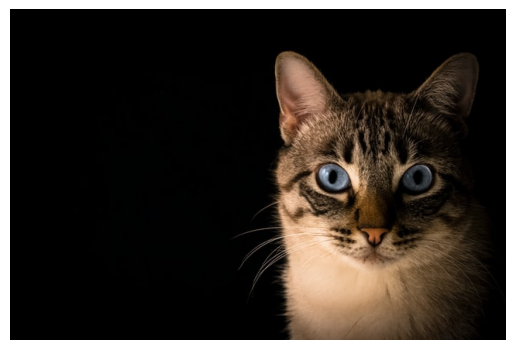

In [ ]:
import cv2
import matplotlib.pyplot as plt


img_path = 'opencv_files 2/cat.jpg'

img = cv2.imread(img_path)

if img is None:
    
    img_path = 'opencv_files 2/cats.jpg'
    img = cv2.imread(img_path)

if img is None:
    print("Error: Still can't find the image. Double-check the exact file name inside the 'opencv_files 2' folder.")
else:
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

## 2. Drawing and Text
**Task:**
1. Create a blank image of size $500 \times 500$ with 3 color channels.
2. Paint a portion of the image red ($[200:300, 300:400]$).
3. Draw a green rectangle from $(0,0)$ to the center of the image.
4. Draw a red circle at the center with a radius of 40.
5. Draw a white line from $(100, 250)$ to $(300, 400)$.



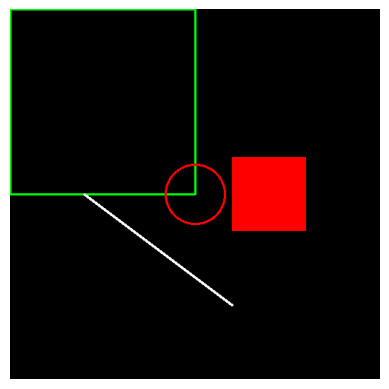

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
blank = np.zeros((500, 500, 3), dtype='uint8')


blank[200:300, 300:400] = [0, 0, 255]

cv2.rectangle(blank, (0, 0), (250, 250), (0, 255, 0), 2)


cv2.circle(blank, (250, 250), 40, (0, 0, 255), 2)

cv2.line(blank, (100, 250), (300, 400), (255, 255, 255), 2)

plt.imshow(cv2.cvtColor(blank, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## 3. Basic Image Functions
**Task:**
1. Load `park.jpg`.
2. Convert it to grayscale.
3. Apply Gaussian Blur with a $(7,7)$ kernel.
4. Perform Canny Edge detection on the blurred image.


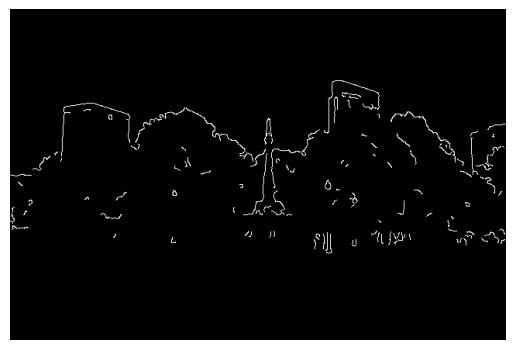

In [1]:
import cv2
import matplotlib.pyplot as plt


img = cv2.imread('opencv_files 2/park.jpg')

if img is None:
    print("Error: Still can't find park.jpg! Check if the folder name is exactly 'opencv_files 2'")
else:
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    
    blur = cv2.GaussianBlur(gray, (7, 7), 0)

    
    canny = cv2.Canny(blur, 125, 175)

    
    plt.imshow(canny, cmap='gray')  
    plt.axis('off')
    plt.show()

## 4. Image Transformations
**Task:**
1. Create a function `translate(img, x, y)` to shift an image.
2. Create a function `rotate(img, angle, rotPoint=None)` to rotate an image.
3. Apply a flip transformation to `park.jpg`.

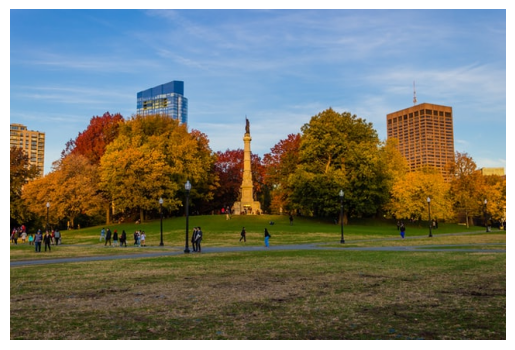

In [3]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('opencv_files 2/park.jpg')


def translate(img, x, y):
    transMat = np.float32([[1, 0, x], [0, 1, y]])
    return cv2.warpAffine(img, transMat, (img.shape[1], img.shape[0]))


def rotate(img, angle, rotPoint=None):
    (h, w) = img.shape[:2]
    if rotPoint is None:
        rotPoint = (w // 2, h // 2)
    rotMat = cv2.getRotationMatrix2D(rotPoint, angle, 1.0)
    return cv2.warpAffine(img, rotMat, (w, h))

flipped = cv2.flip(img, 1)


plt.imshow(cv2.cvtColor(flipped, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


## 5. Contour Detection
**Task:**
1. Load `cats.jpg`.
2. Convert to grayscale and apply Gaussian blur.
3. Find the edges using Canny.
4. Use `cv.findContours` to find all contours.
5. Print the count and draw them on a blank image.

141 contour(s) found!


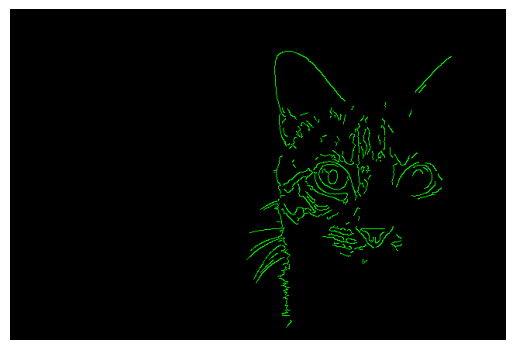

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('opencv_files 2/cats.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)


canny = cv2.Canny(blur, 125, 175)


contours, hierarchies = cv2.findContours(canny, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

print(f'{len(contours)} contour(s) found!')
blank = np.zeros(img.shape, dtype='uint8')
cv2.drawContours(blank, contours, -1, (0, 255, 0), 1)

plt.imshow(cv2.cvtColor(blank, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


## 6. Color Spaces
**Task:**
1. Load `park.jpg`.
2. Convert and display in: Gray, HSV,and RGB.

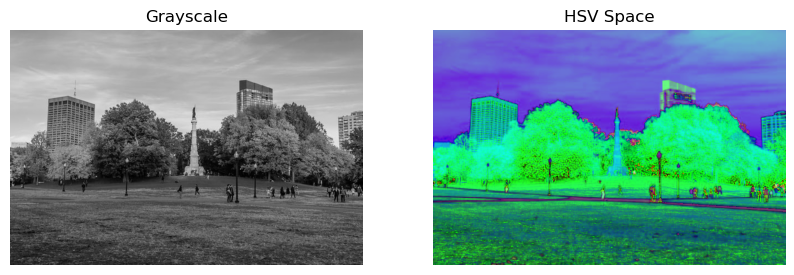

In [5]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('opencv_files 2/park.jpg')


gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Grayscale')
axes[0].axis('off')

axes[1].imshow(hsv)
axes[1].set_title('HSV Space')
axes[1].axis('off')

plt.show()

## 7. Smoothing and Blurring
**Task:**
1. Load `cats.jpg`.
2. Apply Averaging, Gaussian and Median Blurs

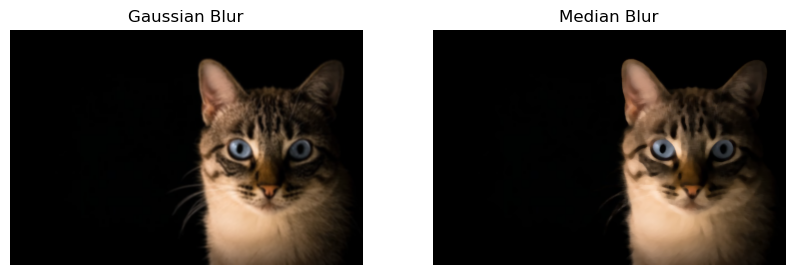

In [7]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread('opencv_files 2/cats.jpg')

gaussian = cv2.GaussianBlur(img, (7, 7), 0)
median = cv2.medianBlur(img, 7)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB))
axes[0].set_title('Gaussian Blur')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(median, cv2.COLOR_BGR2RGB))
axes[1].set_title('Median Blur')
axes[1].axis('off')

plt.show()


## 8. Bitwise Operations
**Task:**
1. Create a $400 \times 400$ blank image.
2. Create a rectangle and a circle on separate blank images.
3. Perform Bitwise AND, OR, XOR, and NOT.

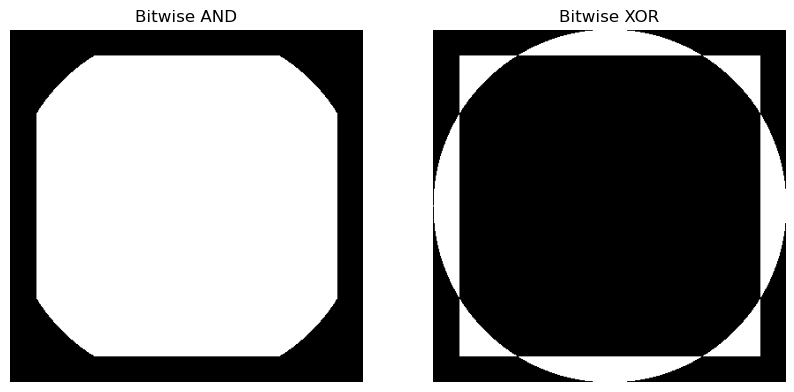

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

blank1 = np.zeros((400, 400), dtype='uint8')
blank2 = np.zeros((400, 400), dtype='uint8')

rectangle = cv2.rectangle(blank1, (30, 30), (370, 370), 255, -1)
circle = cv2.circle(blank2, (200, 200), 200, 255, -1)

bitwise_and = cv2.bitwise_and(rectangle, circle)
bitwise_xor = cv2.bitwise_xor(rectangle, circle)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(bitwise_and, cmap='gray')
axes[0].set_title('Bitwise AND')
axes[0].axis('off')

axes[1].imshow(bitwise_xor, cmap='gray')
axes[1].set_title('Bitwise XOR')
axes[1].axis('off')

plt.show()

## 9. Thresholding
**Task:**
1. Load `cats.jpg` and convert to grayscale.
2. Apply Simple Thresholding (Binary and Inverse).

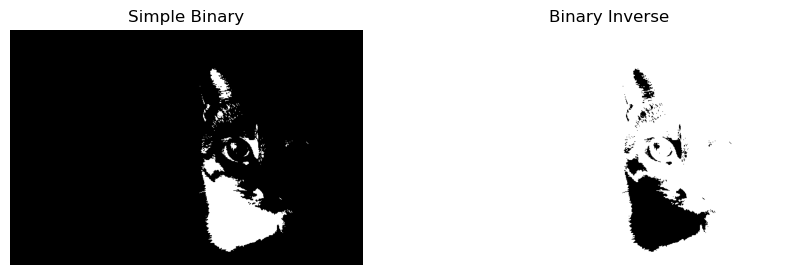

In [10]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread('opencv_files 2/cats.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


threshold, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)
threshold, thresh_inv = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(thresh, cmap='gray')
axes[0].set_title('Simple Binary')
axes[0].axis('off')

axes[1].imshow(thresh_inv, cmap='gray')
axes[1].set_title('Binary Inverse')
axes[1].axis('off')

plt.show()
